## BORDES

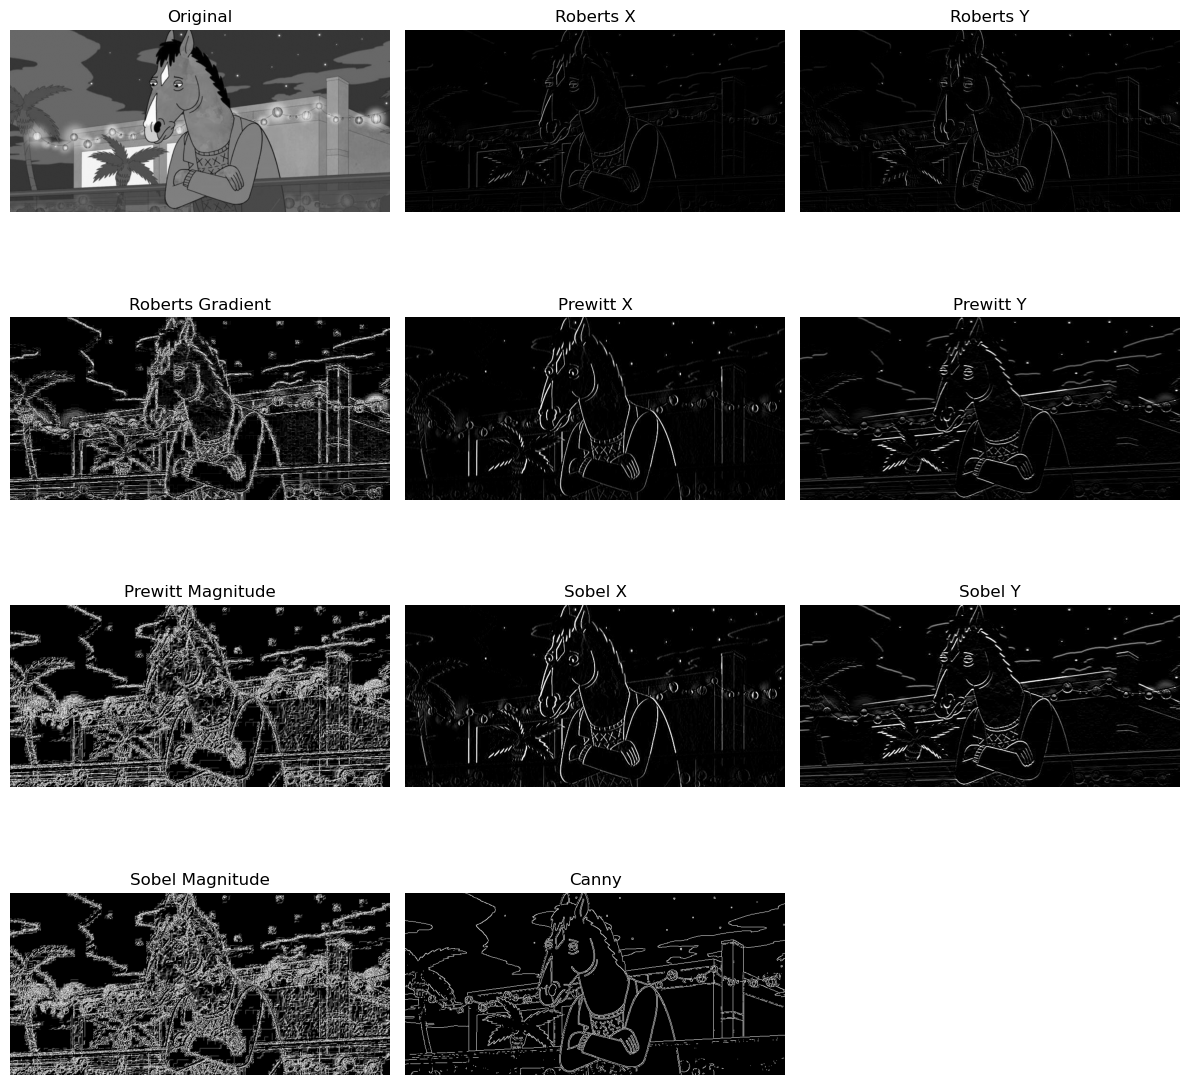

In [14]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

img=cv2.imread('imagen1.jpg')
gray=cv2.cvtColor(img,cv2.COLOR_BGR2GRAY)

robertx=np.array([[-1,0],[0,1]])
roberty=np.array([[0,-1],[1,0]])
robx_img=cv2.filter2D(gray,-1,robertx)
robty_img=cv2.filter2D(gray,-1,roberty)
rob_grad=np.sqrt(robx_img**2+robty_img**2)
rob_grad_dir=np.arctan2(robty_img,robx_img)

#prewit
prewittx=np.array([[-1,0,1],[-1,0,1],[-1,0,1]])
prewitty=np.array([[-1,-1,-1],[0,0,0],[1,1,1]])
prex_img=cv2.filter2D(gray,-1,prewittx)
prey_img=cv2.filter2D(gray,-1,prewitty)
prewitt_mag=np.sqrt(prex_img**2+prey_img**2)
prewitt_dir=np.arctan2(prex_img,prey_img)

#sobel

sobel_x=np.array([[-1,0,1],[-2,0,2],[-1,0,1]])
sobel_y=np.array([[-1,-2,-1],[0,0,0],[1,2,1]])
sobelx_img=cv2.filter2D(gray,-1,sobel_x)
sobely_img=cv2.filter2D(gray,-1,sobel_y)
sobel_mag=np.sqrt(sobelx_img**2+sobely_img**2)
sobel_dir=np.arctan2(sobely_img,sobelx_img)

cany_img=cv2.Canny(gray,100,100)

plt.figure(figsize=(12,12))

plt.subplot(4,3,1), plt.imshow(gray,cmap='gray'), plt.title('Original'), plt.axis('off')
plt.subplot(4,3,2), plt.imshow(robx_img,cmap='gray'), plt.title('Roberts X'), plt.axis('off')
plt.subplot(4,3,3), plt.imshow(robty_img,cmap='gray'), plt.title('Roberts Y'), plt.axis('off')

plt.subplot(4,3,4), plt.imshow(rob_grad,cmap='gray'), plt.title('Roberts Gradient'), plt.axis('off')
plt.subplot(4,3,5), plt.imshow(prex_img,cmap='gray'), plt.title('Prewitt X'), plt.axis('off')
plt.subplot(4,3,6), plt.imshow(prey_img,cmap='gray'), plt.title('Prewitt Y'), plt.axis('off')

plt.subplot(4,3,7), plt.imshow(prewitt_mag,cmap='gray'), plt.title('Prewitt Magnitude'), plt.axis('off')
plt.subplot(4,3,8), plt.imshow(sobelx_img,cmap='gray'), plt.title('Sobel X'), plt.axis('off')
plt.subplot(4,3,9), plt.imshow(sobely_img,cmap='gray'), plt.title('Sobel Y'), plt.axis('off')

plt.subplot(4,3,10), plt.imshow(sobel_mag,cmap='gray'), plt.title('Sobel Magnitude'), plt.axis('off')
plt.subplot(4,3,11), plt.imshow(cany_img,cmap='gray'), plt.title('Canny'), plt.axis('off')

plt.tight_layout()
plt.show()


## SOBEL

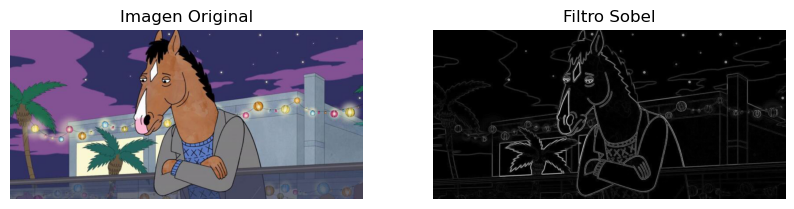

In [17]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

def filtro_sobel(img):
    img_gris=cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    g_x=cv2.Sobel(img_gris,cv2.CV_64F,1,0,ksize=3)
    g_y=cv2.Sobel(img_gris,cv2.CV_64F,0,1,ksize=3)

    mag=np.sqrt(np.square(g_x)+np.square(g_y))
    mag=cv2.normalize(mag,None,0,255,cv2.NORM_MINMAX,cv2.CV_8U)
    return mag

img=cv2.imread('imagen1.jpg')

plt.figure(figsize=(10,5))
plt.subplot(1,2,1)
plt.imshow(cv2.cvtColor(img,cv2.COLOR_BGR2RGB))
plt.title('Imagen Original')
plt.axis('off')
sobel_result=filtro_sobel(img)
plt.subplot(1,2,2)
plt.imshow(sobel_result,cmap='gray')
plt.title('Filtro Sobel')
plt.axis('off')
plt.show()

## SOBEL MEJORADO

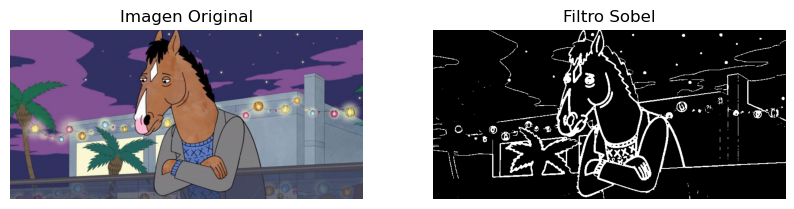

In [16]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

def filtro_sobel_mejorado(img,kernel_size=3,umbral=30):
    img_gris=cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

    #para mejorar la deteccion filtro gauss
    img_gris=cv2.GaussianBlur(img_gris,(3,3),0)
    g_x=cv2.Sobel(img_gris,cv2.CV_64F,1,0,ksize=kernel_size)
    g_y=cv2.Sobel(img_gris,cv2.CV_64F,0,1,ksize=kernel_size)

    # mag=np.sqrt(np.square(g_x)+np.square(g_y))
    mag=np.sqrt(g_x**2 + g_y**2)
    mag=cv2.normalize(mag,None,0,255,cv2.NORM_MINMAX,cv2.CV_8U)
    _,bordes=cv2.threshold(mag,umbral,255,cv2.THRESH_BINARY+cv2.THRESH_OTSU)
    
    #operacion morth unir bordes rotos
    kernel_m=np.ones((2,2),np.uint8)
    bordes=cv2.morphologyEx(bordes,cv2.MORPH_CLOSE,kernel_m)
    return bordes

img=cv2.imread('imagen1.jpg')

plt.figure(figsize=(10,5))
plt.subplot(1,2,1)
plt.imshow(cv2.cvtColor(img,cv2.COLOR_BGR2RGB))
plt.title('Imagen Original')
plt.axis('off')
sobel_result=filtro_sobel_mejorado(img)
plt.subplot(1,2,2)
plt.imshow(sobel_result,cmap='gray')
plt.title('Filtro Sobel')
plt.axis('off')
plt.show()

## FILTRO ROBERTS

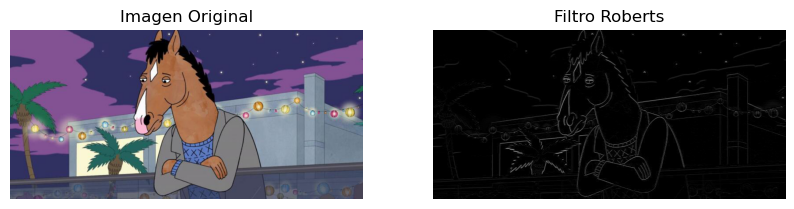

In [18]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

def filtro_roberts(img):
    img_gris=cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

    robertx=np.array([[-1,0],[0,1]],dtype=np.float32)
    roberty=np.array([[0,-1],[1,0]],dtype=np.float32)
    r_x=cv2.filter2D(img_gris,-1,robertx)
    r_y=cv2.filter2D(img_gris,-1,roberty)
    roberts=cv2.addWeighted(r_x,0.5,r_y,0.5,0)
    return roberts

img=cv2.imread('imagen1.jpg')
plt.figure(figsize=(10,5))
plt.subplot(1,2,1)
plt.imshow(cv2.cvtColor(img,cv2.COLOR_BGR2RGB))
plt.title('Imagen Original')
plt.axis('off')
roberts_result=filtro_roberts(img)
plt.subplot(1,2,2)
plt.imshow(roberts_result,cmap='gray')
plt.title('Filtro Roberts'), plt.axis('off')
plt.show()